Student Performance Prediction System

Project Overview

The objective of this project is to analyze the factors affecting student academic performance and build a machine learning model capable of predicting final exam scores.

The dataset contains information related to study habits, attendance, sleep patterns, social media usage, internet usage, previous academic performance, and participation in extracurricular activities.

Objectives

* Generate a synthetic dataset of student records.
* Perform data cleaning and preprocessing.
* Conduct exploratory data analysis (EDA).
* Visualize relationships between different features and exam performance.
* Train a machine learning model to predict final exam scores.
* Evaluate model performance using MAE, RMSE, and R² Score.
* Create a prediction system for estimating student exam scores.


In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)

num_students = 1000

student_ids = np.arange(1, num_students + 1)

study_hours = np.random.uniform(1, 8, num_students)

attendance = np.random.uniform(50, 100, num_students)

sleep_hours = np.random.uniform(4, 10, num_students)

social_media = np.random.uniform(0, 6, num_students)

previous_score = np.random.uniform(40, 100, num_students)

activities = np.random.randint(0, 2, num_students)

internet_usage = np.random.uniform(1, 10, num_students)

final_score = (
    study_hours * 4
    + attendance * 0.3
    + sleep_hours * 2
    - social_media * 1.5
    + previous_score * 0.5
    + activities * 3
    + np.random.normal(0, 5, num_students)
)

final_score = np.clip(final_score, 0, 100)

df = pd.DataFrame({
    "StudentID": student_ids,
    "StudyHoursPerDay": study_hours,
    "AttendancePercentage": attendance,
    "SleepHours": sleep_hours,
    "SocialMediaHours": social_media,
    "PreviousExamScore": previous_score,
    "ParticipationInActivities": activities,
    "InternetUsageHours": internet_usage,
    "FinalExamScore": final_score
})

df.to_csv("data/student_performance.csv", index=False)

print("Dataset Created Successfully!")
print(df.head())

Dataset Created Successfully!
   StudentID  StudyHoursPerDay  AttendancePercentage  SleepHours  \
0          1          3.621781             59.256646    5.570234   
1          2          7.655000             77.095047    5.481873   
2          3          6.123958             93.647292    9.437527   
3          4          5.190609             86.611244    5.497277   
4          5          2.092130             90.328057    5.631698   

   SocialMediaHours  PreviousExamScore  ParticipationInActivities  \
0          4.036218          74.319753                          0   
1          4.780088          88.325940                          1   
2          1.502807          85.609656                          0   
3          3.749245          49.233994                          1   
4          3.430476          48.954968                          1   

   InternetUsageHours  FinalExamScore  
0            5.668731       73.141489  
1            1.460490      100.000000  
2            3.095727     

   StudentID  StudyHoursPerDay  AttendancePercentage  SleepHours  \
0          1          3.621781             59.256646    5.570234   
1          2          7.655000             77.095047    5.481873   
2          3          6.123958             93.647292    9.437527   
3          4          5.190609             86.611244    5.497277   
4          5          2.092130             90.328057    5.631698   

   SocialMediaHours  PreviousExamScore  ParticipationInActivities  \
0          4.036218          74.319753                          0   
1          4.780088          88.325940                          1   
2          1.502807          85.609656                          0   
3          3.749245          49.233994                          1   
4          3.430476          48.954968                          1   

   InternetUsageHours  FinalExamScore  
0            5.668731       73.141489  
1            1.460490      100.000000  
2            3.095727      100.000000  
3            5.4

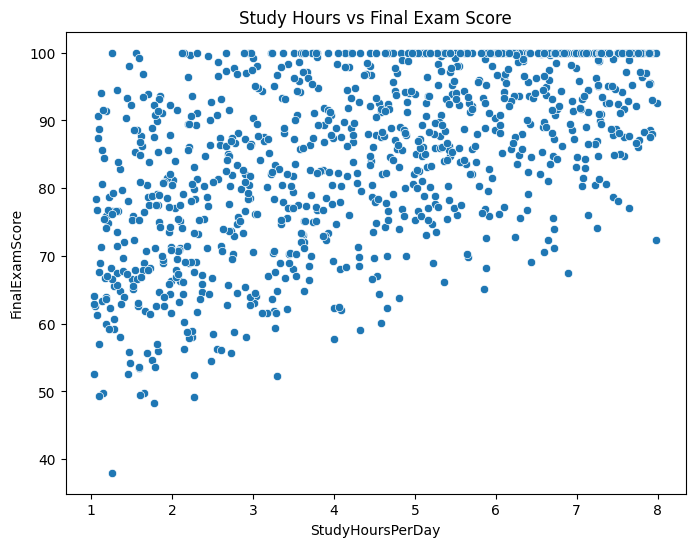

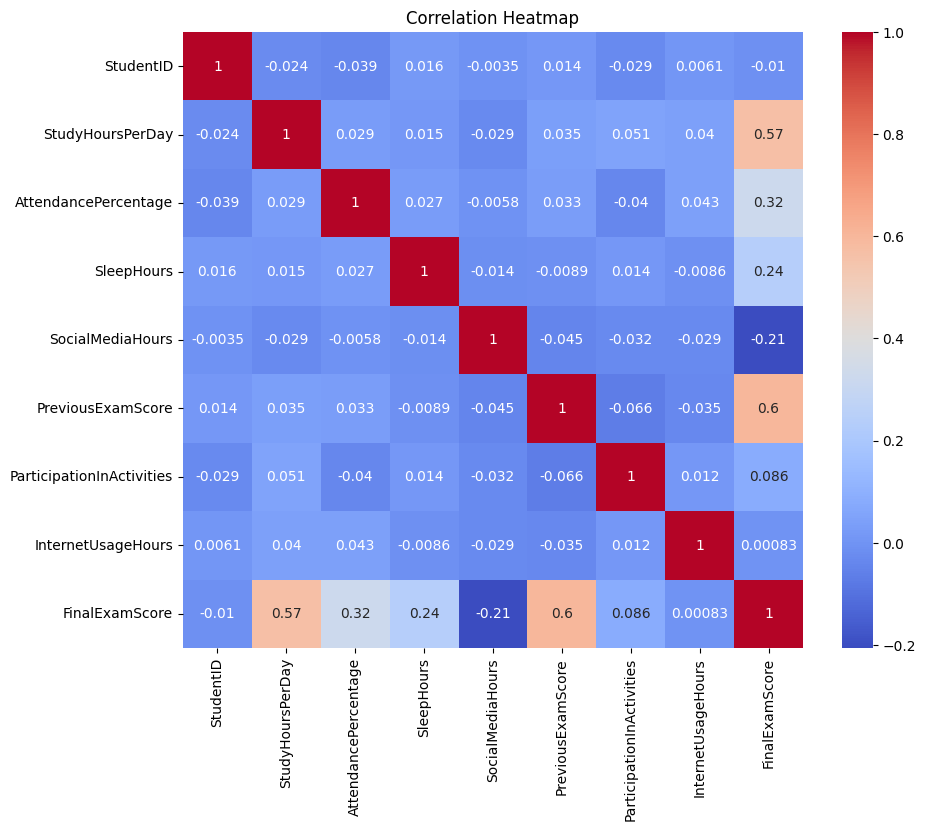

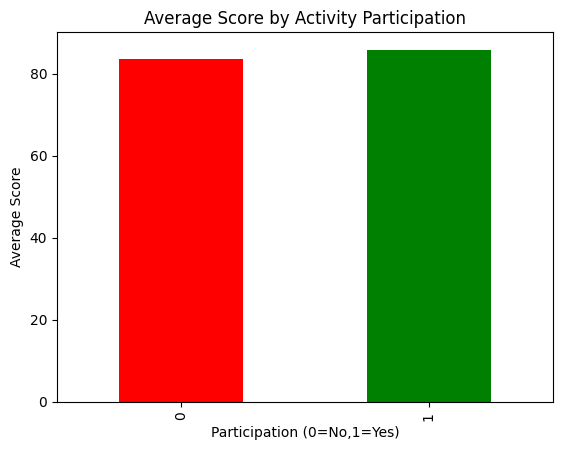

In [5]:
import pandas as pd

df = pd.read_csv("data/student_performance.csv")

print(df.head())
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())
print(
    df[['StudyHoursPerDay', 'FinalExamScore']].corr()
)
print(
    df[['AttendancePercentage', 'FinalExamScore']].corr()
)
print(
    df[['SleepHours', 'FinalExamScore']].corr()
)
print(
    df[['SocialMediaHours', 'FinalExamScore']].corr()
)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='StudyHoursPerDay',
    y='FinalExamScore',
    data=df
)

plt.title("Study Hours vs Final Exam Score")

plt.show()
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()
activity_scores = (
    df.groupby(
        'ParticipationInActivities'
    )['FinalExamScore'].mean()
)

activity_scores.plot(
    kind='bar',
    color=['red', 'green']
)

plt.title(
    'Average Score by Activity Participation'
)

plt.xlabel('Participation (0=No,1=Yes)')
plt.ylabel('Average Score')

plt.show()

In [6]:
import pandas as pd

df = pd.read_csv("data/student_performance.csv")

print(df.head())
X = df.drop(
    ['StudentID', 'FinalExamScore'],
    axis=1
)

y = df['FinalExamScore']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")
predictions = model.predict(X_test)

print(predictions[:5])
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("\nModel Evaluation")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)
import joblib

joblib.dump(model, "student_model.pkl")

print("Model saved successfully!")
import pandas as pd

df = pd.read_csv("data/student_performance.csv")

print(df.head())
X = df.drop(
    ['StudentID', 'FinalExamScore'],
    axis=1
)

y = df['FinalExamScore']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")
predictions = model.predict(X_test)

print(predictions[:5])
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("\nModel Evaluation")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)
import joblib

joblib.dump(model, "student_model.pkl")

print("Model saved successfully!")


   StudentID  StudyHoursPerDay  AttendancePercentage  SleepHours  \
0          1          3.621781             59.256646    5.570234   
1          2          7.655000             77.095047    5.481873   
2          3          6.123958             93.647292    9.437527   
3          4          5.190609             86.611244    5.497277   
4          5          2.092130             90.328057    5.631698   

   SocialMediaHours  PreviousExamScore  ParticipationInActivities  \
0          4.036218          74.319753                          0   
1          4.780088          88.325940                          1   
2          1.502807          85.609656                          0   
3          3.749245          49.233994                          1   
4          3.430476          48.954968                          1   

   InternetUsageHours  FinalExamScore  
0            5.668731       73.141489  
1            1.460490      100.000000  
2            3.095727      100.000000  
3            5.4

In [7]:
import joblib
import numpy as np

model = joblib.load("student_model.pkl")

print("Student Performance Prediction System")
print("------------------------------------")

try:
    study_hours = float(input("Study Hours Per Day: "))
    attendance = float(input("Attendance Percentage: "))
    sleep_hours = float(input("Sleep Hours: "))
    social_media = float(input("Social Media Hours: "))
    previous_score = float(input("Previous Exam Score: "))
    activities = int(input("Participation in Activities (0/1): "))
    internet_usage = float(input("Internet Usage Hours: "))

except ValueError:
    print("Invalid input!")
    exit()

features = np.array([[
    study_hours,
    attendance,
    sleep_hours,
    social_media,
    previous_score,
    activities,
    internet_usage
]])

prediction = model.predict(features)

print("\nPredicted Final Exam Score:")
print(round(prediction[0], 2))

Student Performance Prediction System
------------------------------------

Predicted Final Exam Score:
103.23
